# Tarea N°1: Selección de Atributos con Naive Bayes

**Curso:** Ingeniería de Atributos y Modelos de Machine Learning

**Objetivo:** predecir si un préstamo no será devuelto por completo (`not.fully.paid = 1`) con un clasificador Naive Bayes, y encontrar el conjunto más pequeño de atributos que mantenga el F1-score y mejore el *recall* de la clase minoritaria.

**Dataset:** [Loan Data (Kaggle)](https://www.kaggle.com/datasets/itssuru/loan-data)

## Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score, classification_report, ConfusionMatrixDisplay)


a) Disponer en colab el dataset Loan Data. identificar como clase el atributo ‘not.fully.paid’.
Separar los datos en un conjunto de entrenamiento, reservando el 33 % para testing, usando
random_state=125 para que luego podamos comparar nuestros resultados. Estrictamente hablando, en esta tarea el segundo sería un set de validación, dado que se usará para comparar la performance
de varios clasificadores, en este caso de un mismo modelo pero entrenados con diferentes sets de
atributos.

In [8]:
# El archivo loan_data.csv se descarga de Kaggle: https://www.kaggle.com/datasets/itssuru/loan-data
# (en Colab, subirlo desde el panel de Archivos)
df = pd.read_csv('loan_data.csv')
df.head()


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


#### Atributos categóricos
Se observa que el atributo 'purpose' es de tipo 'object'. Dado que queremos que todos los atributos sean numéricos, la estrategia consiste en separar esta columna y agregar 7 columnas adicionales, una para cada propósito, utilizando get_dummies para binarizar los valores de la columna 'purpose'.

En este caso, las categorías no tienen un orden explícito, por lo que no es posible aplicar un *ordinal encoding*.

In [10]:
df_num = pd.get_dummies(df, columns=['purpose'])
df_num.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,False,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,False,True,False,False,False,False,False


In [11]:
#Analizamos el balance de clases

print(df_num.shape)

ncl0 = len(df_num[df_num['not.fully.paid']==0])
ncl1 = len(df_num[df_num['not.fully.paid']==1])
ncl  = ncl0 + ncl1

print('Num de clases 0:', ncl0,'||','Num de clases 1:', ncl1)
print('porcentaje de clases 0:', ncl0/ncl, '||', 'Porcentaje de clase 1:', ncl1/ncl)


(9578, 20)
Num de clases 0: 8045 || Num de clases 1: 1533
porcentaje de clases 0: 0.8399457089162664 || Porcentaje de clase 1: 0.16005429108373356


Antes de balancear las clases, vamos a entrenar con el modelo como está para analizar las métricas.

In [12]:
X = df_num.drop('not.fully.paid', axis=1)
y = df_num['not.fully.paid']

test_fraction = 0.33

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_fraction, stratify=y, random_state=125)

print(len(X_train),len(X_test))


6417 3161


b) Implementar el clasificador Naïve Bayes usando Scikit-learn. para predecir la clase y evaluar con las mismas métricas usadas en la guía 2. Atender en la documentación de scikit-learn sobre
f1 score a las opciónes del parámetro average. Utilizar en esta tarea la opción weighted que tiene
en cuenta el desbalance de clase. Para recall y precision usar pos_label=1 dado que suponemos
de interés a la clase minoritaria.


In [13]:
# Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)
y_predict = model.predict(X_test)

In [14]:
#Evaluación del modelo

accuracy = accuracy_score(y_test, y_predict)
recall = recall_score(y_test, y_predict, pos_label=1)  # clase positiva = 1 (préstamos no devueltos)
precision = precision_score(y_test, y_predict, pos_label=1)
f1 = f1_score(y_test, y_predict, average='weighted')

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1:", f1)

Accuracy: 0.8187282505536223
Recall: 0.07905138339920949
Precision: 0.272108843537415
f1: 0.7746390251749721


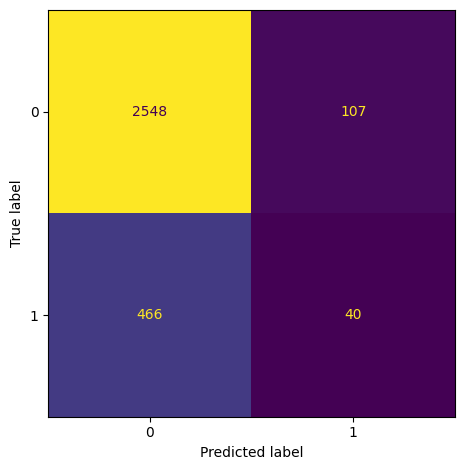

In [15]:
#Matriz de confusión

ConfusionMatrixDisplay.from_predictions(y_test, y_predict, colorbar=False)

plt.tight_layout()
plt.show()

#### Balanceo de clases.
Las clases están muy desbalanceadas, hay un 84% de personas que devuelven el préstamo y un 16% que no. Esto puede traer problemas a la hora de entrenar el modelo, por lo que se considera una buena práctica balancear las clases.

Como los nuevos ejemplos que lleguen estarán desbalanceados, quiero mantener X_test tal como está y balancear únicamente el conjunto de entrenamiento X_train. Es importante destacar que no puedo utilizar el DataFrame df_num, ya que podría correr el riesgo de incluir ejemplos destinados al entrenamiento dentro del conjunto de prueba. Por lo tanto, trabajo con X_train, añadiendo la columna de las clases y luego balanceo este nuevo DataFrame. El proceso de balanceo consiste en seleccionar aleatoriamente un número de ejemplos de la clase mayoritaria igual al de la clase minoritaria, que en este caso se seleccionan 1000 ejemplos de la clase 0 (las personas que sí pagan el préstamo).

In [16]:
X_train['not.fully.paid'] = y_train
X_train

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business,not.fully.paid
3303,1,0.1126,59.16,10.085809,8.60,722,1559.958333,2297,26.1,1,0,0,False,False,False,True,False,False,False,0
5070,1,0.1461,517.13,10.915088,6.74,677,5222.000000,306,38.2,1,3,0,False,False,True,False,False,False,False,0
4769,1,0.1426,171.53,10.926669,8.17,667,4289.958333,9685,43.2,1,0,0,False,False,True,False,False,False,False,0
1187,1,0.0832,236.14,10.819778,2.42,762,3180.000000,4880,38.1,0,0,0,True,False,False,False,False,False,False,0
1114,1,0.0832,113.35,9.402612,6.14,727,4110.958333,2877,70.2,0,0,0,False,False,True,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2238,1,0.1316,118.20,10.778956,19.60,687,2610.000000,13632,50.7,1,0,0,True,False,False,False,False,False,False,0
6378,1,0.1114,82.01,10.308953,19.88,757,2280.041667,1781,35.6,0,0,0,False,True,False,False,False,False,False,0
8134,0,0.1141,65.87,8.411833,4.00,667,330.000000,333,37.0,4,0,0,False,False,False,True,False,False,False,0
3642,1,0.1253,334.67,10.736310,8.90,692,2009.958333,9158,52.3,2,0,0,False,False,True,False,False,False,False,0


In [17]:
df_0 = X_train[X_train['not.fully.paid'] == 0]
df_1 = X_train[X_train['not.fully.paid'] == 1]
df_0 = df_0.sample(n=1000, random_state = 125)
dfb  = pd.concat([df_1,df_0])

print(dfb.shape)

ncl0 = len(dfb[dfb['not.fully.paid']==0])
ncl1 = len(dfb[dfb['not.fully.paid']==1])
ncl = ncl0 + ncl1

print('Num de clases 0:', ncl0, '||','Num de clases 1:', ncl1)
print('porcentaje de clases 0:', ncl0/ncl, '||', 'Porcentaje de clase 1:', ncl1/ncl)

(2027, 20)
Num de clases 0: 1000 || Num de clases 1: 1027
porcentaje de clases 0: 0.493339911198816 || Porcentaje de clase 1: 0.506660088801184


In [18]:
dfb.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business,not.fully.paid
1539,1,0.1178,662.19,10.858999,15.42,727,3755.041667,25971,66.6,0,0,0,False,False,True,False,False,False,False,1
5097,1,0.1287,403.60,11.156251,22.47,697,4080.000000,13260,66.6,2,0,0,False,False,True,False,False,False,False,1
9354,0,0.1496,83.15,10.165852,19.62,687,1110.000000,1388,55.5,4,0,0,True,False,False,False,False,False,False,1
6770,1,0.1426,111.50,9.923290,22.41,667,3450.041667,7986,81.5,1,0,1,False,False,True,False,False,False,False,1
6650,1,0.1218,133.20,10.621327,16.65,697,1920.041667,1649,22.6,3,0,0,False,False,True,False,False,False,False,1


In [19]:
dfb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2027 entries, 1539 to 1575
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   credit.policy               2027 non-null   int64  
 1   int.rate                    2027 non-null   float64
 2   installment                 2027 non-null   float64
 3   log.annual.inc              2027 non-null   float64
 4   dti                         2027 non-null   float64
 5   fico                        2027 non-null   int64  
 6   days.with.cr.line           2027 non-null   float64
 7   revol.bal                   2027 non-null   int64  
 8   revol.util                  2027 non-null   float64
 9   inq.last.6mths              2027 non-null   int64  
 10  delinq.2yrs                 2027 non-null   int64  
 11  pub.rec                     2027 non-null   int64  
 12  purpose_all_other           2027 non-null   bool   
 13  purpose_credit_card         2027 no

In [20]:
# Solo se balancea el set de entrenamiento: X_test se deja sin balancear
# porque los ejemplos nuevos van a llegar desbalanceados.

Xb_train = dfb.drop('not.fully.paid', axis=1)
yb_train = dfb['not.fully.paid']


In [21]:
#Training

modelb = GaussianNB()
modelb.fit(Xb_train, yb_train)
yb_predict = modelb.predict(X_test)     #notar que el X_test no lo tocamos

In [22]:
#Model evaluation
accuracy = accuracy_score(y_test, yb_predict)
recall = recall_score(y_test, yb_predict, pos_label=1)  # clase positiva = 1 (préstamos no devueltos)
precision = precision_score(y_test, yb_predict, pos_label=1)
f1 = f1_score(y_test, yb_predict, average='weighted')

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1:", f1)

Accuracy: 0.7763366023410313
Recall: 0.2628458498023715
Precision: 0.284796573875803
f1: 0.7726695137286358


In [23]:
print(classification_report(y_test, yb_predict))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87      2655
           1       0.28      0.26      0.27       506

    accuracy                           0.78      3161
   macro avg       0.57      0.57      0.57      3161
weighted avg       0.77      0.78      0.77      3161



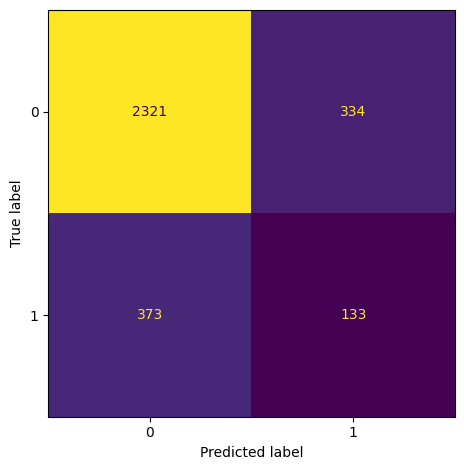

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, yb_predict, colorbar=False)

plt.tight_layout()
plt.show()

### Entrenar tirando de a una columna
c) A continuación se desea averiguar cuales son los atributos relevantes en la clasificación de este problema y entender cómo la eliminación de algunos de ellos incide en las métricas de evaluación usadas.

En este paso, utilizaré un bucle for para eliminar, una por una, las columnas que no pertenecen a 'purpose', mientras registro las métricas en una lista y construyo un DataFrame con esos resultados. Luego, eliminaré las 7 columnas de 'purpose' y reportaré las métricas en otro DataFrame, que contendrá una única fila. Finalmente, concatenaré ambos DataFrames de resultados para poder visualizarlos de manera más clara.

In [25]:
#lista para ir guardando los resultados
results = []

columns = Xb_train.columns[:-7]

for col in columns:
    # Drop the current column
    Xb_train_temp = Xb_train.drop(col, axis=1)
    X_test_temp = X_test.drop(col, axis=1)

    # Train the model
    model = GaussianNB()
    model.fit(Xb_train_temp, yb_train)
    y_predict = model.predict(X_test_temp)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_predict)
    recall = recall_score(y_test, y_predict, pos_label=1)
    precision = precision_score(y_test, y_predict, pos_label=1)
    f1 = f1_score(y_test, y_predict, average='weighted')

    # Store the results
    results.append({
        'Dropped Column': col,
        'Accuracy': accuracy,
        'Recall': recall,
        'Precision': precision,
        'F1 Score': f1
    })

# Convert results to DataFrame for easy viewing

results_df = pd.DataFrame(results)

# Display the results
print(results_df)

       Dropped Column  Accuracy    Recall  Precision  F1 Score
0       credit.policy  0.774438  0.252964   0.276458  0.770340
1            int.rate  0.776337  0.262846   0.284797  0.772670
2         installment  0.785511  0.260870   0.302752  0.778937
3      log.annual.inc  0.772857  0.262846   0.278243  0.770221
4                 dti  0.780133  0.252964   0.287640  0.774330
5                fico  0.788358  0.187747   0.269122  0.772474
6   days.with.cr.line  0.775071  0.256917   0.279570  0.771184
7           revol.bal  0.693135  0.484190   0.256813  0.726078
8          revol.util  0.786460  0.231225   0.290323  0.776393
9      inq.last.6mths  0.745650  0.250988   0.230072  0.750068
10        delinq.2yrs  0.774755  0.264822   0.282700  0.771752
11            pub.rec  0.775388  0.266798   0.284810  0.772393


In [26]:
#entrenamos sin las columnas 'purpose'

columnstodrop1 = [
'purpose_credit_card',
'purpose_debt_consolidation',
'purpose_educational',
'purpose_home_improvement',
'purpose_major_purchase',
'purpose_small_business',
'purpose_all_other']

X1_train = dfb.drop(['not.fully.paid'], axis=1).drop(columnstodrop1, axis=1)
y1_train = dfb['not.fully.paid']
X1_test = X_test.drop(columnstodrop1, axis=1)


In [27]:
#Training

model = GaussianNB()
model.fit(X1_train, y1_train)
y_predict = model.predict(X1_test)

In [28]:
# Model evaluation

accuracy1 = accuracy_score(y_test, y_predict)
recall1 = recall_score(y_test, y_predict, pos_label=1)
precision1 = precision_score(y_test, y_predict, pos_label=1)
f11 = f1_score(y_test, y_predict, average='weighted')


results1 = []
results1.append({
'Dropped Column': 'purpose',
'Accuracy': accuracy1,
'Recall': recall1,
'Precision': precision1,
'F1 Score': f11
})

#quiero hacer un DataFrame con 'results1'

results1_df = pd.DataFrame(results1)



In [ ]:
#Concateno los dos dataframes de resultados y ordeno la columna 'recall' de manera descendente

df_resultados = pd.concat([results_df, results1_df], axis=0)
df_resultados = df_resultados.sort_values(by='Recall', ascending=False)
df_resultados

d) Usando la información del dataframe generado y experimentos de prueba y error, determinar cuál
es el conjunto más pequeño de atributos necesarios para clasificar manteniendo (casi) invariante
f1-score pero mejorando recall de la clase de interés (1) por lo menos a 0.2. Declarar cuáles
son esas variables, reportar las métricas que se consiguen usando solo estos atributos y mostrar la
matriz de confusión resultante.


Se observa que hay atributos que cuando los elimino, aumenta la métrica 'recall'. Es por eso que como primera estrategia voy a tirar aquellos atributos con 'recall' más alto.

A continuación se van a eliminar distintos atributos y se analizarán las métricas para decidir qué columnas mantener. Nos concentraremos principalmente en la métrica 'Recall' debido a que esta nos dará una idea de a qué tipo de ejemplos no hay que darles un préstamo porque no lo devuelven... sin descuidar el 'Accuracy' que nos dice qué tan bien estamos clasificando. Además, queremos dejar (casi) invariante f1-score.

In [30]:
#entrenamos sin las siguientes columnas (Recall alto cuando las tiramos)

columnstodrop3 = [
'purpose_credit_card',
'purpose_debt_consolidation',
'purpose_educational',
'purpose_home_improvement',
'purpose_major_purchase',
'purpose_small_business',
'purpose_all_other',
'revol.bal',
'pub.rec',
'delinq.2yrs']



X2_train = dfb.drop(['not.fully.paid'], axis=1).drop(columnstodrop3, axis=1)
y2_train = dfb['not.fully.paid']
X2_test = X_test.drop(columnstodrop3, axis=1)




In [31]:
#Training

modelb = GaussianNB()
modelb.fit(X2_train, y2_train)
yb_predict = modelb.predict(X2_test)


In [32]:
#Model evaluation

accuracy = accuracy_score(y_test, yb_predict)
recall = recall_score(y_test, yb_predict, pos_label=1)
precision = precision_score(y_test, yb_predict, pos_label=1)
f1 = f1_score(y_test, yb_predict, average='weighted')

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1:", f1)

Accuracy: 0.7146472635242012
Recall: 0.4288537549407115
Precision: 0.26144578313253014
f1: 0.7399770301459125


Se observa que el Recall aumenta y Accuracy se mantiene en 0.7. En el paso siguiente voy a eliminar la columna 'int.rate' (que es la que le sigue con recall mas alto).

In [33]:
#entrenamos sin las siguientes columnas (Recall alto cuando las tiramos)



columnstodrop4 = [
'purpose_credit_card',
'purpose_debt_consolidation',
'purpose_educational',
'purpose_home_improvement',
'purpose_major_purchase',
'purpose_small_business',
'purpose_all_other',
'revol.bal',
'pub.rec',
'delinq.2yrs',
'int.rate']

X3_train = dfb.drop(['not.fully.paid'], axis=1).drop(columnstodrop4, axis=1)
y3_train = dfb['not.fully.paid']
X3_test = X_test.drop(columnstodrop4, axis=1)


In [34]:
#Training

modelb = GaussianNB()
modelb.fit(X3_train, y3_train)
yb_predict = modelb.predict(X3_test)

In [35]:
#Model evaluation

accuracy = accuracy_score(y_test, yb_predict)
recall = recall_score(y_test, yb_predict, pos_label=1)
precision = precision_score(y_test, yb_predict, pos_label=1)
f1 = f1_score(y_test, yb_predict, average='weighted')

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1:", f1)

Accuracy: 0.7181271749446377
Recall: 0.4209486166007905
Precision: 0.2626387176325524
f1: 0.7421776748270843


En este caso disminuyó tanto el 'Recall' como 'Accuracy'. Por eso decidí dejar ese atributo y eliminar 'log.annual.inc' que es el atributo que sigue en el DataFrame 'df_resultados' con 'recall' más alto.

In [36]:
columnstodrop5 = [
'purpose_credit_card',
'purpose_debt_consolidation',
'purpose_educational',
'purpose_home_improvement',
'purpose_major_purchase',
'purpose_small_business',
'purpose_all_other',
'revol.bal',
'pub.rec',
'delinq.2yrs',
'log.annual.inc']

X4_train = dfb.drop(['not.fully.paid'], axis=1).drop(columnstodrop5, axis=1)
y4_train = dfb['not.fully.paid']
X4_test = X_test.drop(columnstodrop5, axis=1)


In [37]:
#Training

modelb = GaussianNB()
modelb.fit(X4_train, y4_train)
yb_predict = modelb.predict(X4_test)

In [38]:
#Model evaluation

accuracy = accuracy_score(y_test, yb_predict)
recall = recall_score(y_test, yb_predict, pos_label=1)
precision = precision_score(y_test, yb_predict, pos_label=1)
f1 = f1_score(y_test, yb_predict, average='weighted')

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1:", f1)

Accuracy: 0.7159126858589054
Recall: 0.424901185770751
Precision: 0.2615571776155718
f1: 0.7407242861037953


In [39]:
columnstodrop6 = [
'purpose_credit_card',
'purpose_debt_consolidation',
'purpose_educational',
'purpose_home_improvement',
'purpose_major_purchase',
'purpose_small_business',
'purpose_all_other',
'revol.bal',
'pub.rec',
'delinq.2yrs',
'installment']

X5_train = dfb.drop(['not.fully.paid'], axis=1).drop(columnstodrop6, axis=1)
y5_train = dfb['not.fully.paid']
X5_test = X_test.drop(columnstodrop6, axis=1)

In [40]:
#Training

modelb = GaussianNB()
modelb.fit(X5_train, y5_train)
yb_predict = modelb.predict(X5_test)

In [41]:
#Model evaluation

accuracy = accuracy_score(y_test, yb_predict)
recall = recall_score(y_test, yb_predict, pos_label=1)
precision = precision_score(y_test, yb_predict, pos_label=1)
f1 = f1_score(y_test, yb_predict, average='weighted')

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1:", f1)

Accuracy: 0.7212907307813983
Recall: 0.40711462450592883
Precision: 0.2617534942820839
f1: 0.7437892763535068


Se puede ver que si elimino uno por uno los atributos 'log.annual.inc', 'int.rate' y 'installment', se reportan casi las mismas métricas. Por lo que decidí quedarme solo con 'installment' porque me da mejor 'Recall' cuando elimino las otras dos y 'Accuracy' no varía mucho.

En el paso siguiente voy a eliminar 'days.with.cr.line'.


In [42]:
columnstodrop7 = [
'purpose_credit_card',
'purpose_debt_consolidation',
'purpose_educational',
'purpose_home_improvement',
'purpose_major_purchase',
'purpose_small_business',
'purpose_all_other',
'revol.bal',
'pub.rec',
'log.annual.inc',
'delinq.2yrs',
'int.rate',
'days.with.cr.line']

X6_train = dfb.drop(['not.fully.paid'], axis=1).drop(columnstodrop7, axis=1)
y6_train = dfb['not.fully.paid']
X6_test = X_test.drop(columnstodrop7, axis=1)

In [43]:

#Training

modelb = GaussianNB()
modelb.fit(X6_train, y6_train)
yb_predict = modelb.predict(X6_test)

In [44]:
#Model evaluation

accuracy = accuracy_score(y_test, yb_predict)
recall = recall_score(y_test, yb_predict, pos_label=1)
precision = precision_score(y_test, yb_predict, pos_label=1)
f1 = f1_score(y_test, yb_predict, average='weighted')

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1:", f1)

Accuracy: 0.7250869977855109
Recall: 0.40118577075098816
Precision: 0.26397919375812745
f1: 0.7462778892927819


Se observa que 'Recall' se mantiene y que 'Accuracy' aumenta. En el paso siguiente voy a eliminar 'credit.policy'.

In [45]:
columnstodrop8 = [
'purpose_credit_card',
'purpose_debt_consolidation',
'purpose_educational',
'purpose_home_improvement',
'purpose_major_purchase',
'purpose_small_business',
'purpose_all_other',
'revol.bal',
'pub.rec',
'log.annual.inc',
'delinq.2yrs',
'int.rate',
'days.with.cr.line',
'credit.policy']

X7_train = dfb.drop(['not.fully.paid'], axis=1).drop(columnstodrop8, axis=1)
y7_train = dfb['not.fully.paid']
X7_test = X_test.drop(columnstodrop8, axis=1)

In [46]:
#Training

modelb = GaussianNB()
modelb.fit(X7_train, y7_train)
yb_predict = modelb.predict(X7_test)

In [47]:
#Model evaluation

accuracy = accuracy_score(y_test, yb_predict)
recall = recall_score(y_test, yb_predict, pos_label=1)
precision = precision_score(y_test, yb_predict, pos_label=1)
f1 = f1_score(y_test, yb_predict, average='weighted')

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1:", f1)

Accuracy: 0.6257513445112306
Recall: 0.5059288537549407
Precision: 0.21530698065601345
f1: 0.6735312977892497


En este caso, 'Recall' aumenta pero 'Accuracy' y 'f1' disminuye, por eso decido que es un atributo que voy a dejar.

A continuación tiro 'dti'.

In [48]:
columnstodrop9 = [
'purpose_credit_card',
'purpose_debt_consolidation',
'purpose_educational',
'purpose_home_improvement',
'purpose_major_purchase',
'purpose_small_business',
'purpose_all_other',
'revol.bal',
'pub.rec',
'log.annual.inc',
'delinq.2yrs',
'int.rate',
'days.with.cr.line',
'dti']

X8_train = dfb.drop(['not.fully.paid'], axis=1).drop(columnstodrop9, axis=1)
y8_train = dfb['not.fully.paid']
X8_test = X_test.drop(columnstodrop9, axis=1)

X8_test.head()

,credit.policy,installment,fico,revol.util,inq.last.6mths
3641,1,53.07,702,94.1,1
7453,1,466.35,722,59.7,0
7105,1,309.22,732,62.7,1
5336,1,556.10,667,98.3,1
5782,1,238.96,682,44.4,0


In [49]:
#Training

modelb = GaussianNB()
modelb.fit(X8_train, y8_train)
yb_predict = modelb.predict(X8_test)

In [50]:
#Model evaluation

accuracy = accuracy_score(y_test, yb_predict)
recall = recall_score(y_test, yb_predict, pos_label=1)
precision = precision_score(y_test, yb_predict, pos_label=1)
f1 = f1_score(y_test, yb_predict, average='weighted')

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1:", f1)

Accuracy: 0.732046820626384
Recall: 0.4031620553359684
Precision: 0.27236315086782376
f1: 0.7515629394787544


'Recall' se mantiene y 'Accuracy' aumenta un poquito. En el paso siguiente voy a eliminar 'inq.last.6mths'.

In [51]:
columnstodrop10 = [
'purpose_credit_card',
'purpose_debt_consolidation',
'purpose_educational',
'purpose_home_improvement',
'purpose_major_purchase',
'purpose_small_business',
'purpose_all_other',
'revol.bal',
'pub.rec',
'log.annual.inc',
'delinq.2yrs',
'int.rate',
'days.with.cr.line',
'dti',
'inq.last.6mths']

X9_train = dfb.drop(['not.fully.paid'], axis=1).drop(columnstodrop10, axis=1)
y9_train = dfb['not.fully.paid']
X9_test = X_test.drop(columnstodrop10, axis=1)

In [52]:
#Training

modelb = GaussianNB()
modelb.fit(X9_train, y9_train)
yb_predict = modelb.predict(X9_test)

In [53]:
#Model evaluation

accuracy = accuracy_score(y_test, yb_predict)
recall = recall_score(y_test, yb_predict, pos_label=1)
precision = precision_score(y_test, yb_predict, pos_label=1)
f1 = f1_score(y_test, yb_predict, average='weighted')

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1:", f1)

Accuracy: 0.6333438785194558
Recall: 0.5316205533596838
Precision: 0.2258606213266163
f1: 0.6801925207804315


'Recall' aumenta bastante, sin embargo 'Accuracy' y 'f1' disminuyen, por esta razón me voy a quedar con el atributo 'inq.last.6mths'.

En el paso siguiente voy a eliminar 'revol.util'

In [54]:
columnstodrop11 = [
'purpose_credit_card',
'purpose_debt_consolidation',
'purpose_educational',
'purpose_home_improvement',
'purpose_major_purchase',
'purpose_small_business',
'purpose_all_other',
'revol.bal',
'pub.rec',
'log.annual.inc',
'delinq.2yrs',
'int.rate',
'days.with.cr.line',
'dti',
'revol.util']

X10_train = dfb.drop(['not.fully.paid'], axis=1).drop(columnstodrop11, axis=1)
y10_train = dfb['not.fully.paid']
X10_test = X_test.drop(columnstodrop11, axis=1)

In [55]:
#Training

modelb = GaussianNB()
modelb.fit(X10_train, y10_train)
yb_predict = modelb.predict(X10_test)

In [56]:
#Model evaluation

accuracy = accuracy_score(y_test, yb_predict)
recall = recall_score(y_test, yb_predict, pos_label=1)
precision = precision_score(y_test, yb_predict, pos_label=1)
f1 = f1_score(y_test, yb_predict, average='weighted')

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1:", f1)

Accuracy: 0.7447010439734262
Recall: 0.3814229249011858
Precision: 0.28093158660844253
f1: 0.759563122960589


'Recall' se mantiene y 'Accuracy' aumenta asi que decido eliminar el atributo 'revol.util'. Por último voy a sacar el atributo 'fico'.

In [57]:
columnstodrop12 = [
'purpose_credit_card',
'purpose_debt_consolidation',
'purpose_educational',
'purpose_home_improvement',
'purpose_major_purchase',
'purpose_small_business',
'purpose_all_other',
'revol.bal',
'pub.rec',
'log.annual.inc',
'delinq.2yrs',
'int.rate',
'days.with.cr.line',
'dti',
'revol.util',
'fico']

X11_train = dfb.drop(['not.fully.paid'], axis=1).drop(columnstodrop12, axis=1)
y11_train = dfb['not.fully.paid']
X11_test = X_test.drop(columnstodrop12, axis=1)

In [58]:
#Training

modelb = GaussianNB()
modelb.fit(X11_train, y11_train)
yb_predict = modelb.predict(X11_test)

In [59]:
#Model evaluation

accuracy = accuracy_score(y_test, yb_predict)
recall = recall_score(y_test, yb_predict, pos_label=1)
precision = precision_score(y_test, yb_predict, pos_label=1)
f1 = f1_score(y_test, yb_predict, average='weighted')

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1:", f1)

Accuracy: 0.7459664663081303
Recall: 0.38537549407114624
Precision: 0.2838427947598253
f1: 0.7607548794762737


In [60]:
X11_train.head()

,credit.policy,installment,inq.last.6mths
1539,1,662.19,0
5097,1,403.60,2
9354,0,83.15,4
6770,1,111.50,1
6650,1,133.20,3


In [ ]:
# Matriz de confusión del modelo final (3 atributos)
ConfusionMatrixDisplay.from_predictions(y_test, yb_predict, colorbar=False)

plt.tight_layout()
plt.show()

### Conclusión

El objetivo de este trabajo era experimentar con el dataframe generado para determinar cuál es el conjunto más pequeño de atributos necesarios para clasificar manteniendo casi invariante f1-score pero mejorando el recall de la clase 1 (por lo menos a 0.2).

El conjunto más pequeño que obtuve contiene solo tres atributos: 'credit.policy', 'installment' y 'inq.last.6mths'. Con las siguientes métricas:

**Accuracy:** 0.746

**Recall:** 0.385

**Precision:** 0.284

**F1 (weighted):** 0.761

Es posible que muchos atributos estén correlacionados y, por lo tanto, proporcionen información redundante. Por esta razón, es importante realizar este tipo de análisis para trabajar con un conjunto de datos lo más pequeño posible.

Como mejora a futuro, la selección de atributos podría automatizarse con un bucle o con herramientas de scikit-learn como `SequentialFeatureSelector`.
